# Potencial Gravitacional en un Disco Protoplanetario
Implementación de Poisson en coordenadas cilíndricas usando Gauss-Seidel y SOR.

# Discretización de la ecuación de Poisson en coordenadas cilíndricas

La ecuación del potencial gravitacional es

$$
\frac{\partial^2 \Phi}{\partial r^2}
+
\frac{1}{r}\frac{\partial \Phi}{\partial r}
+
\frac{\partial^2 \Phi}{\partial z^2}
=
4\pi G \rho(r,z)
$$

Utilizando diferencias finitas centradas:

$$
\frac{\partial^2 \Phi}{\partial r^2}
\approx
\frac{\Phi_{i+1,j}-2\Phi_{i,j}+\Phi_{i-1,j}}
{\Delta r^2}
$$

$$
\frac{\partial \Phi}{\partial r}
\approx
\frac{\Phi_{i+1,j}-\Phi_{i-1,j}}
{2\Delta r}
$$

$$
\frac{\partial^2 \Phi}{\partial z^2}
\approx
\frac{\Phi_{i,j+1}-2\Phi_{i,j}+\Phi_{i,j-1}}
{\Delta z^2}
$$

Sustituyendo en la ecuación de Poisson:

$$
\frac{\Phi_{i+1,j}-2\Phi_{i,j}+\Phi_{i-1,j}}
{\Delta r^2}
+
\frac{1}{r_i}
\frac{\Phi_{i+1,j}-\Phi_{i-1,j}}
{2\Delta r}
+
\frac{\Phi_{i,j+1}-2\Phi_{i,j}+\Phi_{i,j-1}}
{\Delta z^2}
=
4\pi G \rho_{i,j}
$$

Agrupando términos:

$$
\left(
\frac{2}{\Delta r^2}
+
\frac{2}{\Delta z^2}
\right)\Phi_{i,j}
=
\left(
\frac{1}{\Delta r^2}
+
\frac{1}{2r_i\Delta r}
\right)\Phi_{i+1,j}
+
\left(
\frac{1}{\Delta r^2}
-
\frac{1}{2r_i\Delta r}
\right)\Phi_{i-1,j}
+
\frac{\Phi_{i,j+1}+\Phi_{i,j-1}}
{\Delta z^2}
-
4\pi G \rho_{i,j}
$$

Finalmente, despejando el potencial en el nodo $(i,j)$:

$$
\Phi_{i,j}
=
\frac{
\left(
\frac{1}{\Delta r^2}
+
\frac{1}{2r_i\Delta r}
\right)\Phi_{i+1,j}
+
\left(
\frac{1}{\Delta r^2}
-
\frac{1}{2r_i\Delta r}
\right)\Phi_{i-1,j}
+
\frac{\Phi_{i,j+1}+\Phi_{i,j-1}}
{\Delta z^2}
-
4\pi G \rho_{i,j}
}
{
\frac{2}{\Delta r^2}
+
\frac{2}{\Delta z^2}
}
$$

Esta expresión constituye la fórmula iterativa utilizada por los métodos de Gauss-Seidel y SOR para resolver numéricamente la ecuación de Poisson.

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
# Constants

AU = 1.495978707e13 # cm
G = 6.6743e-8
rho0 = 1e-9 # g/cm^3
Rmax = 10*AU
Zmax = 2*AU

r0 = 3*AU
h = 0.5*AU

Nr, Nz = 50, 21
dr = Rmax/(Nr-1)
dz = 2*Zmax/(Nz-1)

r = np.linspace(dr, Rmax, Nr)
z = np.linspace(-Zmax, Zmax, Nz) #simetrico porque la ia dice q es mejor

R, Z = np.meshgrid(r, z, indexing='ij')

rho = rho0*np.exp(-R/r0)*np.exp(-(Z**2)/(2*h**2))   #\rho_{ij}

Phi = np.zeros((Nr,Nz))

omega = 1.5
tol = 0.1
max_iter = 10000

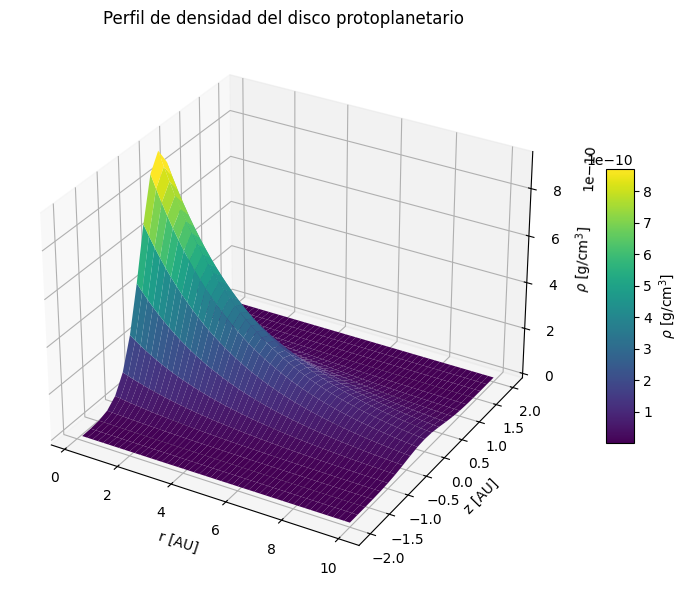

In [158]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    R/AU,
    Z/AU,
    rho,
    cmap='viridis',
    edgecolor='none',
    antialiased=True
)
ax.set_xlabel('r [AU]')
ax.set_ylabel('z [AU]')
ax.set_zlabel(r'$\rho\ \mathrm{[g/cm^3]}$')
ax.set_title('Perfil de densidad del disco protoplanetario')
fig.colorbar(surf, shrink=0.5, aspect=10, label=r'$\rho$ [g/cm$^3$]')
plt.tight_layout()
plt.show()

In [159]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Surface(
            x=R/AU,
            y=Z/AU,
            z=rho,
            colorscale='Viridis',
            colorbar=dict(title=r'$\rho$ [g/cm$^3$]')
        )
    ]
)
fig.update_layout(
    title='Perfil de densidad del disco protoplanetario',
    scene=dict(
        xaxis_title='r [AU]',
        yaxis_title='z [AU]',
        zaxis_title=r'$\rho$ [g/cm$^3$]'
    ),
    width=900,
    height=700
)
fig.show(renderer='browser')

In [160]:
def gauss_seidel(rho, r, Nr, Nz, dr, dz, G,
                 tol=0.1, max_iter=10000):

    Phi = np.zeros((Nr, Nz))

    for it in range(max_iter):

        err_max = 0.0

        for i in range(1, Nr-1):
            for j in range(1, Nz-1):

                ri = r[i]

                A = 1/dr**2 + 1/(2*ri*dr)
                B = 1/dr**2 - 1/(2*ri*dr)
                C = 1/dz**2

                phi_old = Phi[i, j]

                phi_new = (
                    A*Phi[i+1, j]
                    + B*Phi[i-1, j]
                    + C*(Phi[i, j+1] + Phi[i, j-1])
                    - 4*np.pi*G*rho[i, j]
                )/(2/dr**2 + 2/dz**2)

                Phi[i, j] = phi_new

                if abs(phi_new) > 1e-30:
                    eps = abs((phi_new - phi_old)/phi_new)*100
                    err_max = max(err_max, eps)

        if err_max < tol:
            print(f"Gauss-Seidel convergió en {it+1} iteraciones")
            print(f"Error máximo = {err_max:.5f}%")
            return Phi, it+1

    print("Gauss-Seidel no convergió")
    return Phi, max_iter

In [161]:
def sor(rho, r, Nr, Nz, dr, dz, G,
        omega=1.5,
        tol=0.1,
        max_iter=10000):

    Phi = np.zeros((Nr, Nz))

    for it in range(max_iter):

        err_max = 0.0

        for i in range(1, Nr-1):
            for j in range(1, Nz-1):

                ri = r[i]

                A = 1/dr**2 + 1/(2*ri*dr)
                B = 1/dr**2 - 1/(2*ri*dr)
                C = 1/dz**2

                phi_old = Phi[i, j]

                phi_new = (
                    A*Phi[i+1, j]
                    + B*Phi[i-1, j]
                    + C*(Phi[i, j+1] + Phi[i, j-1])
                    - 4*np.pi*G*rho[i, j]
                )/(2/dr**2 + 2/dz**2)

                phi_sor = omega*phi_new + (1-omega)*phi_old

                Phi[i, j] = phi_sor

                if abs(phi_sor) > 1e-30: # Evitar división por cero
                    eps = abs((phi_sor - phi_old)/phi_sor)*100
                    err_max = max(err_max, eps)

        if err_max < tol:
            print(f"SOR convergió en {it+1} iteraciones")
            print(f"Error máximo = {err_max:.5f}%")
            return Phi, it+1

    print("SOR no convergió")
    return Phi, max_iter

In [162]:
Phi_GS, iter_GS = gauss_seidel(
    rho, r, Nr, Nz, dr, dz, G
)

Phi_SOR, iter_SOR = sor(
    rho, r, Nr, Nz, dr, dz, G,
    omega=1.5
)

print("\nComparación:")
print(f"Gauss-Seidel : {iter_GS} iteraciones")
print(f"SOR (ω=1.5)  : {iter_SOR} iteraciones")

Gauss-Seidel convergió en 220 iteraciones
Error máximo = 0.09913%
SOR convergió en 99 iteraciones
Error máximo = 0.09578%

Comparación:
Gauss-Seidel : 220 iteraciones
SOR (ω=1.5)  : 99 iteraciones


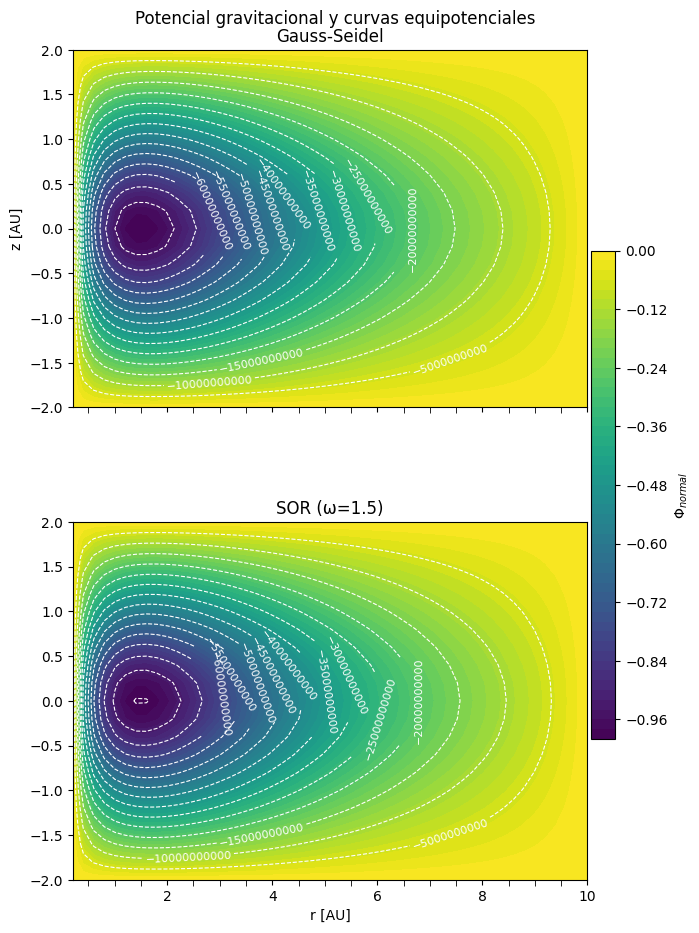

In [163]:
fig, axes = plt.subplots(2, 1, figsize=(7, 10), sharex=True)
solutions = [
    ('Gauss-Seidel', Phi_GS),
    ('SOR (ω=1.5)', Phi_SOR)
]

for ax, (name, phi) in zip(axes, solutions):
    cf = ax.contourf(
        R/AU,
        Z/AU,
        phi / np.abs(phi).max(),
        levels=50,
        cmap='viridis'
    )
    cont = ax.contour(
        R/AU,
        Z/AU,
        phi,
        levels=15,
        colors='white',
        linewidths=0.8
    )
    ax.clabel(cont, inline=True, fontsize=8)
    ax.set_title(name)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='x', which='minor', length=4)

axes[1].set_xlabel('r [AU]')
axes[0].set_ylabel('z [AU]')
fig.suptitle('Potencial gravitacional y curvas equipotenciales')
cb = fig.colorbar(cf, ax=axes, orientation='vertical', fraction=0.045, pad=0.09)
cb.set_label(r'$\Phi_{normal}$')
fig.subplots_adjust(right=0.86, top=0.94, hspace=0.32)

plt.show()

# Comparación de la fuerza radial en el plano medio

Se calcula la fuerza radial en el plano medio $z = 0$ usando
$F_r = -\partial \Phi / \partial r$ y se compara con la fuerza
de un potencial puntual equivalente con la masa total estimada del disco.

Plano medio en z = 0.0000 AU
Masa total estimada del disco: 2.000e+32 g


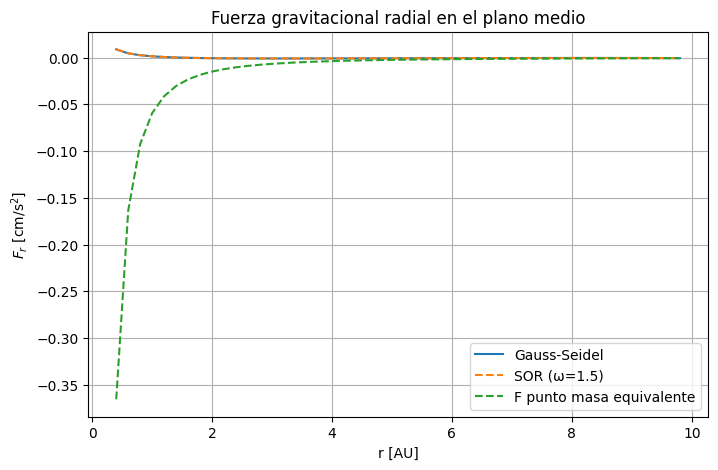

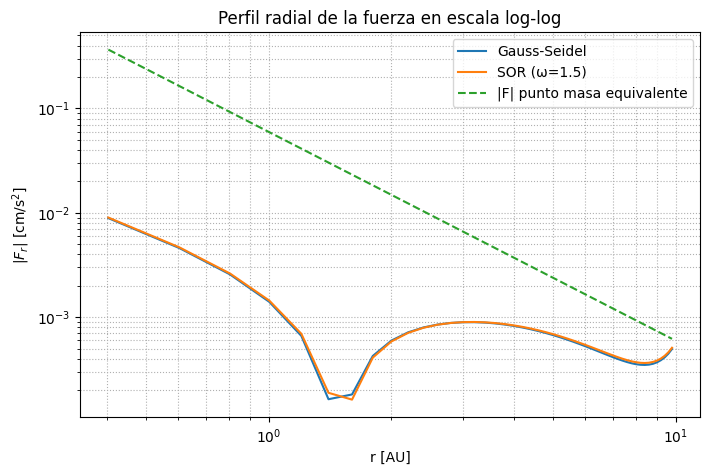

In [164]:
# Fuerza radial a partir del potencial: Fr = -∂Φ/∂r
r_mid = r[1:-1]
z_mid = z[1:-1]

Fr_GS = -(Phi_GS[2:, :] - Phi_GS[:-2, :]) / (2 * dr) # Derivada central en r phi[2:, :] - phi[:-2, :] es phi[i+1, j] - phi[i-1, j]
Fr_SOR = -(Phi_SOR[2:, :] - Phi_SOR[:-2, :]) / (2 * dr) # Derivada central en r 

j_mid = Nz // 2 # Índice del plano medio (viene pq tomo z=np.linspace(-Zmax, Zmax, Nz) y quiero el índice que corresponde a z=0)
z_midplane = z[j_mid]
print(f"Plano medio en z = {z_midplane/AU:.4f} AU")

Fr_GS_mid = Fr_GS[:, j_mid] #proyecto al plano medio
Fr_SOR_mid = Fr_SOR[:, j_mid]

r_mid_au = r_mid / AU

# Masa total estimada del disco (integral en coordenadas cilíndricas)
dz_vals = np.diff(z) #un dz 
sigma = np.sum(0.5 * (rho[:, 1:] + rho[:, :-1]) * dz_vals[None, :], axis=1) #Trapezio en z para obtener rho(r) = integral de rho(r,z) dz
M_disk = 2 * np.pi * np.sum(
    0.5 * (r[1:] * sigma[1:] + r[:-1] * sigma[:-1]) * np.diff(r) 
)#Trapezio en r para obtener masa total integral de 2*pi*r*sigma(r) dr
print(f"Masa total estimada del disco: {M_disk:.3e} g")

Fr_point = -G * M_disk / r_mid**2 #forma kepleriana/masa puntual equivalente

plt.figure(figsize=(8, 5))
plt.plot(r_mid_au, Fr_GS_mid, label='Gauss-Seidel',linestyle='-')
plt.plot(r_mid_au, Fr_SOR_mid, label='SOR (ω=1.5)',linestyle='--')
plt.plot(r_mid_au, Fr_point, '--', label='F punto masa equivalente')

plt.xlabel('r [AU]')
plt.ylabel(r'$F_r$ [cm/s$^2$]')
plt.title('Fuerza gravitacional radial en el plano medio')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.loglog(r_mid_au, np.abs(Fr_GS_mid), label='Gauss-Seidel')
plt.loglog(r_mid_au, np.abs(Fr_SOR_mid), label='SOR (ω=1.5)')
plt.loglog(r_mid_au, np.abs(Fr_point), '--', label='|F| punto masa equivalente')


plt.xlabel('r [AU]')
plt.ylabel(r'$|F_r|$ [cm/s$^2$]')

plt.title('Perfil radial de la fuerza en escala log-log')

plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

## Respuesta a los puntos 4 y 5

**Punto 4. Fuerza gravitacional radial**

Suponiendo que un disco Kepleriano es un disco atraido por una masa central El potencial Gravitacional seria 
$$
\phi=-\frac{GM}{(\sqrt{r^2+z^2})} 
$$
Que en la aproximacion Radial
$$
\phi_r\approx-\frac{GM}{r} 
$$
Usando $$F_r=-\partial \phi_r\propto -\frac{1}{r^2}$$
Los resultados del plot  reflejan que el perfil obtenido no es $\propto-\frac{1}{r^2}$. lo cual tiene sentido no deberia parecerse a un potencial kepleriano ya que es un sistema autogravitante sin masa central dominante y distrubucion gaussiana en Z y exponencial negativa en R. tambien cabe mencionar que para kepler
$$
\nabla^2\phi=4\pi G\rho_0\delta(r-r_0)
$$
Y el ejercio
$$
\nabla^2\phi=4\pi G \rho_0 e^{-r/r_0}e^{-z^2/2h^2}
$$
**Punto 5. Comparación con un potencial puntual**
Es el mismo analisis anterior pero teniendo en Cuenta una masa... en las graficas la linea verde es el pontencia puntal para la masa del disco modelado... otra vez difieren

